In [2]:
import pandas as pd
import numpy as np
from datasets import load_dataset
import matplotlib.pyplot as plt

# loading data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'], errors='coerce')

In [11]:
df_usa = df[df['job_country'] == 'United States'].copy()
df_usa['job_posted_month'] = df_usa['job_posted_date'].dt.month
job_title = df_usa.groupby('job_title_short').count().sort_values(by='job_title', ascending=False).head(3)
job_title_index = job_title.index.tolist()

#only keeping the top 3 in total job numers
df_usa_top3 = df_usa[df_usa['job_title_short'].isin(job_title_index)]

# aggfunc='count' counts only non nan values while aggfunc='size' counts all rows.
#df_usa_top3.pivot_table(index='job_posted_month', columns='job_title_short', values='salary_year_avg', aggfunc='count')
df_usa_top3.pivot_table(index='job_posted_month', columns='job_title_short', values='salary_year_avg', aggfunc='size')


#df_usa_top3.pivot_table(index='job_posted_month', columns='job_title_short', aggfunc='count')
# if no values='salary_year_avg' is chosen, for each column a set of data is printed

job_title_short,Data Analyst,Data Engineer,Data Scientist
job_posted_month,,,
1,8494,2655,6915
2,6124,3060,4956
3,6218,3183,4779
4,6049,2801,4867
5,4993,2976,4377
6,5683,2893,4645
7,5201,2570,4876
8,6634,3269,6318
9,4639,3224,4568


job_title_short   Data Analyst  Data Scientist  Data Engineer
job_posted_month                                             
April                     6049            4867           2801
August                    6634            6318           3269
December                  3979            3472           2641
February                  6124            4956           3060
January                   8494            6915           2655
July                      5201            4876           2570
June                      5683            4645           2893
March                     6218            4779           3183
May                       4993            4377           2976
November                  4531            4175           2793
October                   5271            4882           3015
September                 4639            4568           3224


<Axes: xlabel='job_posted_month'>

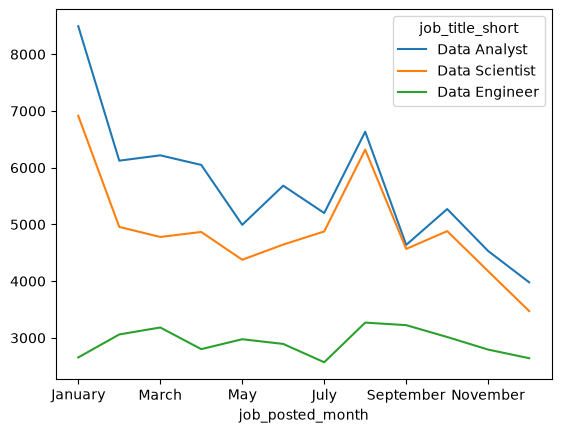

In [12]:
df_usa = df[df['job_country'] == 'United States'].copy()
df_usa['job_posted_month'] = df_usa['job_posted_date'].dt.month_name()
job_title = df_usa.groupby('job_title_short').count().sort_values(by='job_title', ascending=False).head(3)
job_title_index = job_title.index.tolist()

df_usa_pivot = df_usa.pivot_table(index='job_posted_month', columns='job_title_short', values='salary_year_avg', aggfunc='size')
print(df_usa_pivot[job_title_index])

month_order = [
    'January', 'February', 'March', 'April',
    'May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December'
]

df_usa_pivot = df_usa_pivot.reindex(month_order)

df_usa_pivot[job_title_index].plot(kind='line')


job_title_short   Data Analyst  Data Scientist  Data Engineer
job_posted_month                                             
January                   8494            6915           2655
February                  6124            4956           3060
March                     6218            4779           3183
April                     6049            4867           2801
May                       4993            4377           2976
June                      5683            4645           2893
July                      5201            4876           2570
August                    6634            6318           3269
September                 4639            4568           3224
October                   5271            4882           3015
November                  4531            4175           2793
December                  3979            3472           2641


<Axes: xlabel='job_posted_month'>

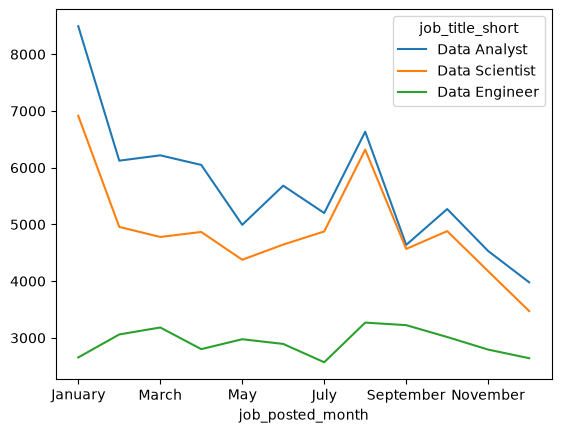

In [ ]:
df_usa = df[df['job_country'] == 'United States'].copy()
df_usa['job_posted_month'] = df_usa['job_posted_date'].dt.month_name()
job_title = df_usa.groupby('job_title_short').count().sort_values(by='job_title', ascending=False).head(3)
job_title_index = job_title.index.tolist()


df_usa_group = df_usa.groupby(['job_posted_month','job_title_short'])['job_title'].size().unstack()
month_order = [
    'January', 'February', 'March', 'April',
    'May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December'
]
df_usa_group = df_usa_group.reindex(month_order)
print(df_usa_group[job_title_index])
df_usa_group[job_title_index].plot(kind='line')

39       January
27      February
6          March
9          April
110          May
0           June
3           July
79        August
26     September
109      October
5       November
89      December
Name: job_posted_month, dtype: str

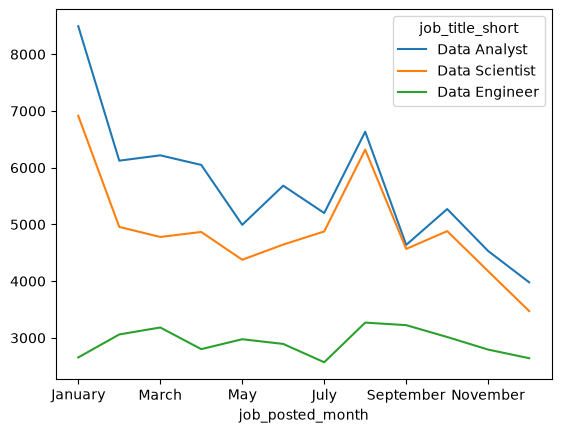

In [13]:
df_usa = df[df['job_country'] == 'United States'].copy()

df_usa['job_posted_month'] = df_usa['job_posted_date'].dt.month_name()
df_usa['job_posted_month_number'] = df_usa['job_posted_date'].dt.month

# Find top 3 job titles
job_title_index = df_usa['job_title_short'].value_counts().head(3).index.tolist()

# Get month names ordered according to month number
month_order = (df_usa[['job_posted_month', 'job_posted_month_number']].drop_duplicates()
    .sort_values('job_posted_month_number')
    ['job_posted_month']
)

# Create pivot table
df_usa_pivot = df_usa.pivot_table(
    index='job_posted_month',
    columns='job_title_short',
    aggfunc='size'
)

# Put months in chronological order
df_usa_pivot = df_usa_pivot.reindex(month_order)

# Keep top 3 jobs
df_usa_pivot[job_title_index].plot(kind='line')
month_order